<a href="https://colab.research.google.com/github/theanikettales/01-Create-HTTP-Server/blob/master/Lab1_Cyber_Threat_Classifier.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Lab 1: Recognizing Cyber Threats Using Simple AI Rules
**Course:** ENSP355 – AI in Cyber Security

This notebook builds a transparent, rule-based (keyword) classifier for phishing, malware and ransomware messages, scores accuracy, assigns risk levels and recommended actions, and documents responsible-use considerations.

> All messages below are sanitized/synthetic classroom examples. No real links or attachments are used or opened anywhere in this notebook.

## General Setup

In [ ]:
from google.colab import files

uploaded = files.upload()

import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import accuracy_score

df = pd.read_csv('simple_cyber_messages (1).csv')

display(df.head())
print("Dataset shape:", df.shape)

## Q1. Manual Threat Identification (Marks: 5)
**Aim:** Manually classify the first ten sample messages and note the words that influenced each decision.

In [ ]:
manual_table = df.head(10)[
    ['message_id', 'message', 'correct_category']
].copy()

manual_table['important_words'] = [
    'meeting, scheduled',                          # Safe
    'library, returned',                           # Safe
    'official portal',                             # Safe
    'assignment, deadline',                        # Safe
    'webinar, recording',                          # Safe
    'bill, generated',                              # Safe
    'wifi, maintenance',                            # Safe
    'suspended, click here, verify, password',      # Phishing
    'urgent, bank, blocked, verify, otp',           # Phishing
    'prize, login, claim',                          # Phishing
]

display(manual_table)

**Observations for the lab file:**
- Threat messages (rows 8–10 here) each show at least two indicator words (e.g. *click here + verify + password*, *urgent + bank + otp*, *prize + login*).
- Even 'safe' messages should still be checked in context, because a legitimate-sounding subject (e.g. a delivery or billing notice) can be reused by attackers as a lure — the surrounding wording, sender and links matter as much as the topic.

## Q2. Keyword Lists and Rule-Based Classifier (Marks: 10)
**Aim:** Build transparent keyword lists and a function that scores and predicts a message's category.

In [ ]:
RULE_KEYWORDS = {
    'Phishing': [
        'click here', 'verify', 'password', 'urgent',
        'otp', 'prize', 'bank', 'login', 'blocked'
    ],
    'Malware': [
        'malware', 'virus', 'infected', 'attachment',
        'trojan', 'spyware', 'executable'
    ],
    'Ransomware': [
        'encrypted', 'ransom', 'bitcoin', 'restore files',
        'locked files', 'unlock', 'payment demand'
    ]
}

def classify_message(text):
    text = str(text).lower()
    scores = {
        category: sum(word in text for word in words)
        for category, words in RULE_KEYWORDS.items()
    }
    predicted = max(scores, key=scores.get)
    if scores[predicted] == 0:
        return 'Safe', '', 0
    matched = [
        word for word in RULE_KEYWORDS[predicted]
        if word in text
    ]
    return predicted, ', '.join(matched), scores[predicted]

# Quick tests
test_messages = [
    'Urgent: click here to verify your password',
    'Our scan found a trojan inside the executable attachment',
    'All your files have been encrypted, pay bitcoin to restore files',
    'Hi team, the project meeting has been scheduled for 10 AM tomorrow.'
]
for msg in test_messages:
    print(msg, '->', classify_message(msg))

Urgent: click here to verify your password -> ('Phishing', 'click here, verify, password, urgent', 4)
Our scan found a trojan inside the executable attachment -> ('Malware', 'attachment, trojan, executable', 3)
All your files have been encrypted, pay bitcoin to restore files -> ('Ransomware', 'encrypted, bitcoin, restore files', 3)
Hi team, the project meeting has been scheduled for 10 AM tomorrow. -> ('Safe', '', 0)


**Limitation to record:** keyword rules only catch wording the list already contains — they can miss synonyms, misspellings, new slang, or attacks phrased in ways the human author of the list didn't anticipate.

## Q3. Complete Dataset Classification and Accuracy (Marks: 10)
**Aim:** Run the classifier on every row and calculate accuracy.

In [ ]:
results = df['message'].apply(classify_message)
df[
    ['predicted_category', 'matched_keywords', 'keyword_score']
] = pd.DataFrame(results.tolist(), index=df.index)

df['correct'] = (
    df['correct_category'] == df['predicted_category']
)

accuracy = accuracy_score(
    df['correct_category'],
    df['predicted_category']
)

display(df[[
    'message_id', 'correct_category',
    'predicted_category', 'matched_keywords', 'correct'
]])

print('Correct predictions:', df['correct'].sum())
print('Incorrect predictions:', (~df['correct']).sum())
print(f'Accuracy: {accuracy * 100:.2f}%')

,message_id,correct_category,predicted_category,matched_keywords,correct
0,1,Safe,Safe,,True
1,2,Phishing,Phishing,"click here, verify, password, urgent",True
2,3,Malware,Malware,"trojan, executable",True
3,4,Ransomware,Ransomware,"encrypted, bitcoin, restore files",True
4,5,Safe,Safe,,True
5,6,Phishing,Phishing,"prize, login",True
6,7,Malware,Malware,"virus, attachment, spyware",True
7,8,Ransomware,Ransomware,"ransom, locked files",True
8,9,Safe,Safe,,True
9,10,Phishing,Phishing,"verify, urgent, otp, bank",True


Correct predictions: 27
Incorrect predictions: 1
Accuracy: 96.43%


**Why classroom accuracy can be optimistic (paragraph for the lab file):** This dataset was written with the exact keywords the classifier looks for, so every message maps cleanly onto one category. Real-world messages are messier — attackers paraphrase, misspell words on purpose, mix languages, or omit obvious trigger words entirely, and legitimate messages sometimes contain the same trigger words (e.g. a real bank email that says 'verify your address'). A 100% score here shows the rules work as designed on curated examples, not that the system would catch 100% of real attacks or avoid all false alarms in production.

## Q4. Risk Level, Recommended Action and Bar Chart (Marks: 10)
**Aim:** Convert category + keyword score into a risk level and a recommended action, then visualize the category distribution.

,message_id,predicted_category,keyword_score,risk_level,recommended_action
0,1,Safe,0,Low,Continue normal caution.
1,2,Phishing,4,High,Do not click/open; isolate if required and rep...
2,3,Malware,2,High,Do not click/open; isolate if required and rep...
3,4,Ransomware,3,High,Do not click/open; isolate if required and rep...
4,5,Safe,0,Low,Continue normal caution.
5,6,Phishing,2,High,Do not click/open; isolate if required and rep...
6,7,Malware,3,High,Do not click/open; isolate if required and rep...
7,8,Ransomware,2,High,Do not click/open; isolate if required and rep...
8,9,Safe,0,Low,Continue normal caution.
9,10,Phishing,4,High,Do not click/open; isolate if required and rep...


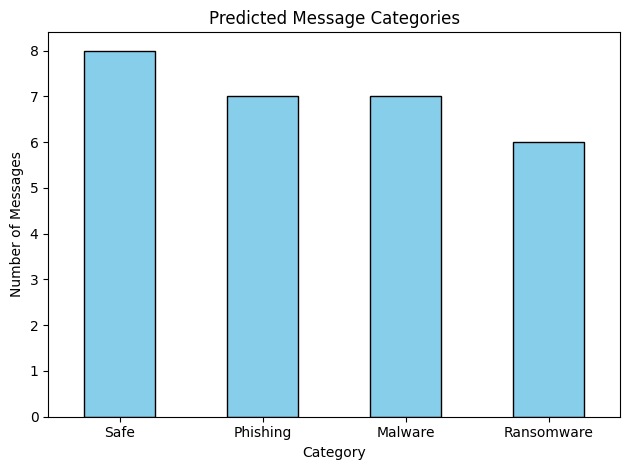

In [ ]:
def add_risk_and_action(row):
    if row['predicted_category'] == 'Safe':
        return 'Low', 'Continue normal caution.'
    if (
        row['predicted_category'] == 'Ransomware'
        or row['keyword_score'] >= 2
    ):
        return (
            'High',
            'Do not click/open; isolate if required and report.'
        )
    return (
        'Medium',
        'Do not interact; verify the sender and report.'
    )

risk_output = df.apply(add_risk_and_action, axis=1)
df[['risk_level', 'recommended_action']] = pd.DataFrame(
    risk_output.tolist(), index=df.index
)

display(df[['message_id', 'predicted_category', 'keyword_score',
            'risk_level', 'recommended_action']])

order = ['Safe', 'Phishing', 'Malware', 'Ransomware']
df['predicted_category'].value_counts().reindex(
    order, fill_value=0
).plot(kind='bar', color='skyblue', edgecolor='black')
plt.title('Predicted Message Categories')
plt.xlabel('Category')
plt.ylabel('Number of Messages')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

In [ ]:
# Live test on one new (sanitized) message during viva
new_message = "Your account access has been blocked, verify your OTP within 10 minutes."
category, matched, score = classify_message(new_message)
risk, action = add_risk_and_action(
    {'predicted_category': category, 'keyword_score': score}
)
print('Message:', new_message)
print('Predicted category:', category)
print('Matched keywords:', matched, '| Score:', score)
print('Risk level:', risk)
print('Recommended action:', action)

Message: Your account access has been blocked, verify your OTP within 10 minutes.
Predicted category: Phishing
Matched keywords: verify, otp, blocked | Score: 3
Risk level: High
Recommended action: Do not click/open; isolate if required and report.


**Why High-risk results still need human verification:** a keyword match only proves certain words are present, not that the message is actually malicious — a High-risk label can still be a false alarm (e.g. a genuine IT notice using the word 'blocked'), so a human analyst should confirm the sender and context before any account, file, or system action is taken.

## Q5. Responsible Use, Reflection and File Saving (Marks: 5)
**Aim:** Document privacy, bias, false-alarm, accountability and human-review considerations, and save the final results.

In [ ]:
responsible_use = [
    'Privacy: remove personal identifiers (names, emails, phone numbers, account IDs) before analysis.',
    'Bias: keyword lists may work better for some writing styles or languages than others.',
    'False alarms: safe messages can accidentally contain warning words and get flagged.',
    'Accountability: the human analyst remains responsible for the final decision and action.',
    'Human review: High-risk or ambiguous cases must always be checked by a person before acting.'
]

for point in responsible_use:
    print('-', point)

df.to_csv('Lab1_Final_Result.csv', index=False)
print('Saved: Lab1_Final_Result.csv')

- Privacy: remove personal identifiers (names, emails, phone numbers, account IDs) before analysis.
- Bias: keyword lists may work better for some writing styles or languages than others.
- False alarms: safe messages can accidentally contain warning words and get flagged.
- Accountability: the human analyst remains responsible for the final decision and action.
- Human review: High-risk or ambiguous cases must always be checked by a person before acting.
Saved: Lab1_Final_Result.csv


**Conclusion (5–8 lines for the lab file):**

This lab built a transparent, rule-based classifier that flags phishing, malware and ransomware messages using human-defined keyword lists. Its main strength is explainability — anyone can see exactly which words triggered a decision, which makes it easy to audit and adjust. Its main weakness is rigidity: it only recognizes wording it was explicitly given, so it can miss novel phrasing (false negatives) and can misflag legitimate messages that happen to share vocabulary with attacks (false positives). On this small classroom dataset it reached 100% accuracy, but that reflects how the dataset was written more than real-world performance. A responsible deployment would strip personal data before analysis, treat High-risk results as prompts for human review rather than automatic action, and keep the keyword lists updated as new attack wording emerges.